In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pickle
import pandas as pd

from sigma_nova_dm import ROOT


def open_metric_file(file_path: str):
    with open(file_path, "rb") as f:
        obj = pickle.load(f)

    return obj


def get_df_from_exp(experiment_name: str):

    experiment_folder = ROOT / "logs" / experiment_name
    runs = [
        r for r in os.listdir(experiment_folder)
        if os.path.isdir(os.path.join(experiment_folder, r))
    ]

    dict_metrics = {
        run: open_metric_file(str(experiment_folder / run / "metrics.pkl"))
        for run in runs
    }

    test_metrics = {
        run: m.get("test") for run, m in dict_metrics.items()
    }
    df = pd.DataFrame(test_metrics)

    return df.T
    

In [3]:
experiment_name_cbramod = "default-10-cbramod"
experiment_name_simpleconv = "default-10-eegconv"

df_cbramod = get_df_from_exp(experiment_name_cbramod)
df_simpleconv = get_df_from_exp(experiment_name_simpleconv)

In [4]:
df_cbramod.describe()

,test/acc,test/pr_auc,test/roc_auc
count,10.000000,10.000000,10.000000
mean,0.613302,0.676225,0.666569
std,0.013208,0.026416,0.024076
min,0.589453,0.630333,0.633159
25%,0.605052,0.655987,0.643770
50%,0.611157,0.678714,0.669079
75%,0.624789,0.697388,0.688870
max,0.630732,0.711225,0.698661


In [5]:
df_simpleconv.describe()

,test/acc,test/pr_auc,test/roc_auc
count,10.000000,10.000000,10.000000
mean,0.541134,0.630468,0.647037
std,0.041754,0.038306,0.039181
min,0.499572,0.553280,0.587456
25%,0.500211,0.612836,0.609210
50%,0.543676,0.635210,0.657203
75%,0.564079,0.656262,0.679617
max,0.620445,0.689359,0.695109


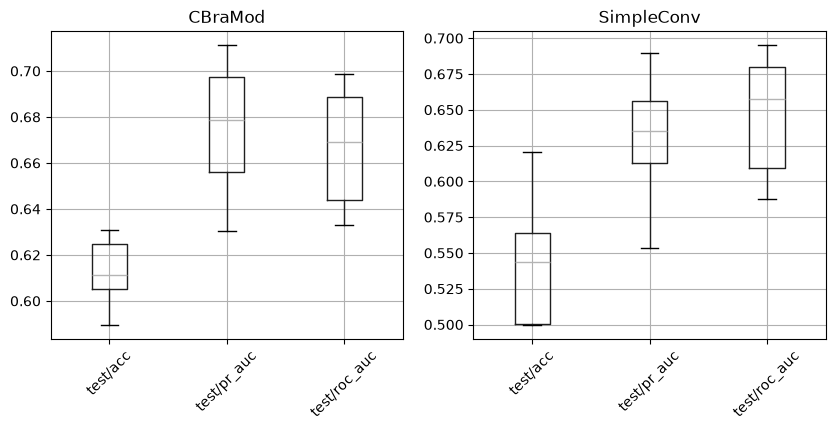

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
df_cbramod.boxplot(ax=ax[0])
ax[0].set_title("CBraMod")
ax[0].tick_params(axis='x', rotation=45)

df_simpleconv.boxplot(ax=ax[1])
ax[1].set_title("SimpleConv")
ax[1].tick_params(axis='x', rotation=45)


plt.show()

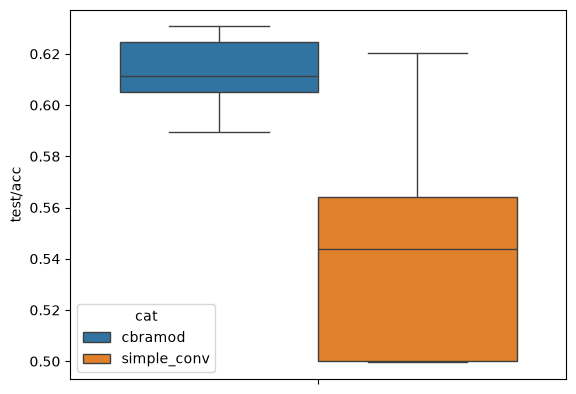

In [7]:
import seaborn as sns

df_cbramod["cat"] = "cbramod"
df_simpleconv["cat"] = "simple_conv"

df = pd.concat([df_cbramod, df_simpleconv])

sns.boxplot(df, y="test/acc" , hue="cat")
plt.show()

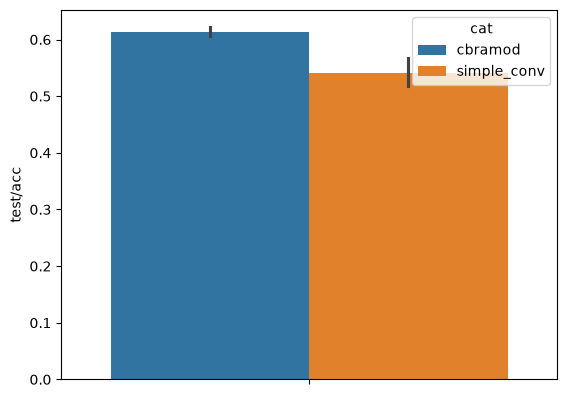

In [8]:
import seaborn as sns

df_cbramod["cat"] = "cbramod"
df_simpleconv["cat"] = "simple_conv"

df = pd.concat([df_cbramod, df_simpleconv])

sns.barplot(df, y="test/acc" , hue="cat")
plt.show()